# Model 2 — Sequence VAE

In [1]:
import os, time, warnings
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from datetime import datetime

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


> **LLM note:** The following cell was generated with Claude assistance (Level 3 skeleton).
> Cleaned up and restructed by Claude and GitHub Copilot.

In [ ]:
# Data source
DATA_MODE       = 'bsm2'                       # 'bsm2' | 'real'
DATA_PATH_BSM2  = 'DATA/BSM2_extracted_data.csv'
DATA_PATH_REAL  = ''
LABELS_PATH     = ''    #
TIMESTAMP_COL   = 'timestamp'
TIMESTAMP_FMT   = '%Y-%m-%d %H:%M:%S'
RESOLUTION_MIN  = 15                           # 15 for BSM2, 10 for real
N_ROWS          = None                         # None = use all rows

# Variables (target + features shared with VAE) 
TARGET_VARS  = ['S_PO4_e']
FEATURE_VARS = [
    'Q_in', 'Temp_in', 'S_PO4_in', 'S_NH4_in', 'S_F_in', 'S_A_in',
    'X_S_in', 'X_TSS_in',
    'S_PO4_r1', 'X_PAO_r1', 'X_PP_r1', 'S_A_r1',
    'S_O2_r5', 'S_PO4_r5', 'S_NH4_r5',
    'S_O2_r7', 'S_PO4_r7', 'X_TSS_r7',
]
# Combined list
ALL_VARS    = TARGET_VARS + [v for v in FEATURE_VARS if v not in TARGET_VARS]
N_VARS      = len(ALL_VARS)
N_TARGETS   = len(TARGET_VARS)
TARGET_IDX  = list(range(N_TARGETS))

# Window length (shared with forecaster)
INPUT_HOURS    = 12
HORIZON_HOURS  = 6                             
INPUT_STEPS    = int(INPUT_HOURS   * 60 / RESOLUTION_MIN)
HORIZON_STEPS  = int(HORIZON_HOURS * 60 / RESOLUTION_MIN)
STRIDE         = INPUT_STEPS // 4

# Splits
TRAIN_RATIO = 0.75; VAL_RATIO = 0.10           # test = for integration

# Active data path 
DATA_PATH = DATA_PATH_BSM2 if DATA_MODE == 'bsm2' else DATA_PATH_REAL


# VAE-specific config
BATCH_SIZE       = 64
EPOCHS           = 300
LEARNING_RATE    = 5e-4
WEIGHT_DECAY     = 1e-5
PATIENCE         = 25

HIDDEN_SIZE      = 192
LATENT_DIM       = 48
NUM_LAYERS       = 2
DROPOUT          = 0.10
BETA             = 0.5
KL_ANNEAL_EPOCHS = 25

BEST_HPARAMS_VAE = {'hidden_size': 192, 'latent_dim': 24, 'num_layers': 1, 'dropout': 0.19391632987783725, 'lr': 0.001441977952572739, 'beta': 0.1370235376560987, 'kl_anneal': 14}  # set after running Optuna cell, if used

print(f'Mode: {DATA_MODE}   n_vars={N_VARS}   window={INPUT_STEPS} steps')

Mode: bsm2   n_vars=19   window=48 steps


> **LLM note:** The following cell was generated with Claude assistance (Level 4 substantial).
> Drafted by Claude, adapted by me, cleaned up and restructed by Claude.

In [ ]:
# DATA LOADING + SCALING + WINDOWING

df = pd.read_csv(DATA_PATH)
df['timestamp'] = pd.to_datetime(df[TIMESTAMP_COL], format=TIMESTAMP_FMT)
df = df.sort_values('timestamp').set_index('timestamp')
if N_ROWS: df = df.iloc[:N_ROWS].copy()
df_model = df[ALL_VARS].copy()
for col in ALL_VARS:
    df_model[col] = (df_model[col]
                     .interpolate('linear', limit_direction='both')
                     .ffill().bfill())

n = len(df_model)
train_end = int(n * TRAIN_RATIO)
val_end   = int(n * (TRAIN_RATIO + VAL_RATIO))

scaler = StandardScaler()
scaler.fit(df_model.values[:train_end])
data_scaled = scaler.transform(df_model.values)

print(f'Data: {n} rows | train={train_end}, val={val_end-train_end}, '
      f'test={n-val_end}')
print(f'Scaler: StandardScaler   |   scaled range '
      f'[{data_scaled[:train_end].min():.2f}, {data_scaled[:train_end].max():.2f}]')

def make_windows(data, L, stride):
    return np.array([data[i:i+L] for i in range(0, len(data)-L+1, stride)])

X_train = make_windows(data_scaled[:train_end],        INPUT_STEPS, STRIDE)
X_val   = make_windows(data_scaled[train_end:val_end], INPUT_STEPS, STRIDE)
X_test  = make_windows(data_scaled[val_end:],          INPUT_STEPS, INPUT_STEPS)
print(f'X_train {X_train.shape}  X_val {X_val.shape}  X_test {X_test.shape}')

class WindowDS(Dataset):
    def __init__(s, X): s.X = torch.FloatTensor(X)
    def __len__(s): return len(s.X)
    def __getitem__(s, i): return s.X[i]

g = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(WindowDS(X_train), BATCH_SIZE, shuffle=True, generator=g)
val_loader   = DataLoader(WindowDS(X_val),   BATCH_SIZE)
test_loader  = DataLoader(WindowDS(X_test),  BATCH_SIZE)

Data: 34944 rows | train=26208, val=3494, test=5242
Scaler: StandardScaler   |   scaled range [-3.99, 6.95]
X_train (2181, 48, 19)  X_val (288, 48, 19)  X_test (109, 48, 19)


> **LLM note:** The following cell was generated with Claude assistance (Level 4 substantial).
> Drafted by Claude, adapted by me, cleaned up and restructed by Claude.

In [ ]:
# MODEL — Sequence VAE

class SeqVAE(nn.Module):
    def __init__(self, n_vars, h, latent, nl, L, dropout=0.0):
        super().__init__()
        self.H, self.D, self.L, self.V, self.NL = h, latent, L, n_vars, nl
        self.enc = nn.LSTM(n_vars, h, nl, batch_first=True, bidirectional=True,
                           dropout=dropout if nl > 1 else 0)
        self.mu_head     = nn.Linear(h * 4, latent)
        self.logvar_head = nn.Linear(h * 4, latent)
        self.pos_emb = nn.Parameter(torch.randn(1, L, h) * 0.02)
        self.z_proj  = nn.Linear(latent, h)
        self.dec = nn.LSTM(h * 2, h, nl, batch_first=True,
                           dropout=dropout if nl > 1 else 0)
        self.out  = nn.Linear(h, n_vars)
        self.drop = nn.Dropout(dropout)
    def encode(self, x):
        h, _ = self.enc(x)
        pooled = torch.cat([h.mean(dim=1), h[:, -1]], dim=1)
        return self.mu_head(pooled), self.logvar_head(pooled)
    def reparameterize(self, mu, lv):
        return mu + torch.exp(0.5*lv) * torch.randn_like(mu)
    def decode(self, z):
        B = z.size(0)
        z_proj = self.z_proj(z).unsqueeze(1).expand(-1, self.L, -1)
        pos    = self.pos_emb.expand(B, -1, -1)
        h, _   = self.dec(torch.cat([z_proj, pos], dim=2))
        return self.out(self.drop(h))
    def forward(self, x):
        mu, lv = self.encode(x); z = self.reparameterize(mu, lv)
        return self.decode(z), mu, lv

def build_vae(hp=None):
    if hp is None: hp = BEST_HPARAMS_VAE
    return SeqVAE(N_VARS,
                  h      = hp.get('hidden_size', HIDDEN_SIZE),
                  latent = hp.get('latent_dim',  LATENT_DIM),
                  nl     = hp.get('num_layers',  NUM_LAYERS),
                  L      = INPUT_STEPS,
                  dropout= hp.get('dropout',     DROPOUT))

model = build_vae().to(DEVICE)
print(f'SeqVAE: {sum(p.numel() for p in model.parameters()):,} params')

SeqVAE: 825,667 params


> **LLM note:** The following cell was generated with Claude assistance (Level 4 substantial).
> Drafted by Claude, adapted by me, cleaned up and restructed by Claude.

In [ ]:
# ELBO + epoch loop

def vae_loss(x, xh, mu, lv, beta):
    recon = F.mse_loss(xh, x, reduction='none').sum(dim=(1, 2)).mean()
    kl    = -0.5 * (1 + lv - mu.pow(2) - lv.exp()).sum(dim=1).mean()
    return recon + beta * kl, recon.detach(), kl.detach()

def run_epoch(model, loader, optimizer=None, beta=1.0):
    train = optimizer is not None
    model.train() if train else model.eval()
    s = {'recon': 0., 'kl': 0.}; n = 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x in loader:
            x = x.to(DEVICE)
            xh, mu, lv = model(x)
            total, recon, kl = vae_loss(x, xh, mu, lv, beta)
            if train:
                optimizer.zero_grad(); total.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            bs = x.size(0)
            s['recon'] += recon.item() * bs; s['kl'] += kl.item() * bs; n += bs
    return {k: v / n for k, v in s.items()}

> **LLM note:** The following cell was generated with Claude assistance (Level 4 substantial).
> Drafted by Claude, adapted by me, cleaned up and restructed by Claude.

In [ ]:
# OPTUNA (dont run after copying best params)

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS       = 50
EPOCHS_TRIAL   = 300
PATIENCE_TRIAL = 25

def _suggest_hp_vae(trial):
    return {
        'hidden_size': trial.suggest_categorical('hidden_size', [64, 96, 128, 192]),
        'latent_dim':  trial.suggest_categorical('latent_dim',  [8, 16, 24, 32]),
        'num_layers':  trial.suggest_int        ('num_layers', 1, 2),
        'dropout':     trial.suggest_float      ('dropout', 0.05, 0.3),
        'lr':          trial.suggest_float      ('lr', 1e-4, 3e-3, log=True),
        'beta':        trial.suggest_float      ('beta', 0.1, 2.0, log=True),
        'kl_anneal':   trial.suggest_int        ('kl_anneal', 10, 40),
    }

def _trial_train_vae(hp):
    torch.manual_seed(SEED)
    m = build_vae(hp).to(DEVICE)
    opt = optim.Adam(m.parameters(), lr=hp['lr'], weight_decay=WEIGHT_DECAY)
    sch = optim.lr_scheduler.ReduceLROnPlateau(opt, 'min', factor=0.5, patience=3)
    best_recon, best_kl, pat = float('inf'), 0.0, 0
    for ep in range(EPOCHS_TRIAL):
        beta = hp['beta'] * min(1.0, ep / max(hp['kl_anneal'], 1))
        run_epoch(m, train_loader, opt, beta=beta)
        vl = run_epoch(m, val_loader, beta=beta)
        sch.step(vl['recon'])
        if vl['recon'] < best_recon: best_recon, best_kl, pat = vl['recon'], vl['kl'], 0
        else: pat += 1
        if pat >= PATIENCE_TRIAL: break
    # Posterior-collapse guard: heavily penalize trials where KL < 0.5
    if best_kl < 0.5:
        return best_recon * 10
    return best_recon

study = optuna.create_study(
    study_name=f'vae_{DATA_MODE}',
    storage=f'sqlite:///optuna__anamoly_vae_{DATA_MODE}.db',
    direction='minimize', load_if_exists=True,
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5))
print(f'── Tuning VAE (existing trials: {len(study.trials)}) ──')
study.optimize(lambda t: _trial_train_vae(_suggest_hp_vae(t)),
               n_trials=N_TRIALS, show_progress_bar=True)
print(f'best recon: {study.best_value:.4f}')
print(f'best params: {study.best_params}')

items = ', '.join(f"'{k}': {v!r}" for k, v in study.best_params.items())
print(f'\nBEST_HPARAMS_VAE = {{{items}}}')

> **LLM note:** The following cell was generated with Claude assistance (Level 4 substantial).
> Drafted by Claude, adapted by me, cleaned up and restructed by Claude.

In [ ]:
# TRAINING

hp = BEST_HPARAMS_VAE
lr_use        = hp.get('lr',        LEARNING_RATE)
beta_use      = hp.get('beta',      BETA)
kl_anneal_use = hp.get('kl_anneal', KL_ANNEAL_EPOCHS)

def kl_beta(epoch):
    if kl_anneal_use <= 0: return beta_use
    return beta_use * min(1.0, epoch / kl_anneal_use)

optimizer = optim.Adam(model.parameters(), lr=lr_use, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=5)

history = {k: [] for k in ['train_recon', 'val_recon', 'train_kl', 'val_kl', 'beta']}
best_val, best_epoch, best_state, pat = float('inf'), 0, None, 0

print(f'Training (lr={lr_use:.1e}, beta={beta_use}, anneal={kl_anneal_use}ep)')
t0 = time.time()
for epoch in range(EPOCHS):
    beta = kl_beta(epoch)
    tl = run_epoch(model, train_loader, optimizer, beta)
    vl = run_epoch(model, val_loader, beta=beta)
    scheduler.step(vl['recon'])
    history['train_recon'].append(tl['recon']); history['val_recon'].append(vl['recon'])
    history['train_kl'].append(tl['kl']);       history['val_kl'].append(vl['kl'])
    history['beta'].append(beta)

    if vl['recon'] < best_val:
        best_val, best_epoch = vl['recon'], epoch + 1
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        pat = 0
    else: pat += 1
    if (epoch + 1) % 10 == 0 or epoch < 3:
        print(f'  ep {epoch+1:3d}  recon={vl["recon"]:.4f}  kl={vl["kl"]:.3f}  '
              f'β={beta:.2f}  pat={pat}/{PATIENCE}')
    if pat >= PATIENCE:
        print(f'  early stop @ ep {epoch+1}'); break

model.load_state_dict(best_state); model = model.to(DEVICE)
train_time_s = time.time() - t0
print(f'Done in {train_time_s:.0f}s  best val recon={best_val:.4f} @ ep {best_epoch}')

final_val_kl = history['val_kl'][best_epoch - 1]
print(f'KL at best epoch: {final_val_kl:.3f}  '
      f'({"OK" if final_val_kl > 1 else "WARNING: posterior collapse"})')

Training (lr=1.4e-03, beta=0.1370235376560987, anneal=14ep)
  ep   1  recon=543.7182  kl=22.205  β=0.00  pat=0/25
  ep   2  recon=307.7859  kl=63.489  β=0.01  pat=0/25
  ep   3  recon=216.1874  kl=65.478  β=0.02  pat=0/25
  ep  10  recon=76.3128  kl=64.376  β=0.09  pat=0/25
  ep  20  recon=50.2486  kl=58.349  β=0.14  pat=0/25
  ep  30  recon=38.0920  kl=57.886  β=0.14  pat=1/25
  ep  40  recon=32.6281  kl=57.608  β=0.14  pat=1/25
  ep  50  recon=29.5925  kl=56.598  β=0.14  pat=1/25
  ep  60  recon=27.3759  kl=56.309  β=0.14  pat=3/25
  ep  70  recon=26.3091  kl=56.275  β=0.14  pat=2/25
  ep  80  recon=22.6182  kl=55.809  β=0.14  pat=0/25
  ep  90  recon=21.7253  kl=55.328  β=0.14  pat=0/25
  ep 100  recon=21.2858  kl=55.758  β=0.14  pat=4/25
  ep 110  recon=21.2063  kl=55.330  β=0.14  pat=2/25
  ep 120  recon=20.5941  kl=55.587  β=0.14  pat=0/25
  ep 130  recon=20.8072  kl=55.390  β=0.14  pat=9/25
  ep 140  recon=20.5578  kl=55.369  β=0.14  pat=0/25
  ep 150  recon=20.6662  kl=55.448  

> **LLM note:** The following cell was generated with Claude assistance (Level 4 substantial).
> Drafted by Claude, adapted by me, cleaned up and restructed by Claude.

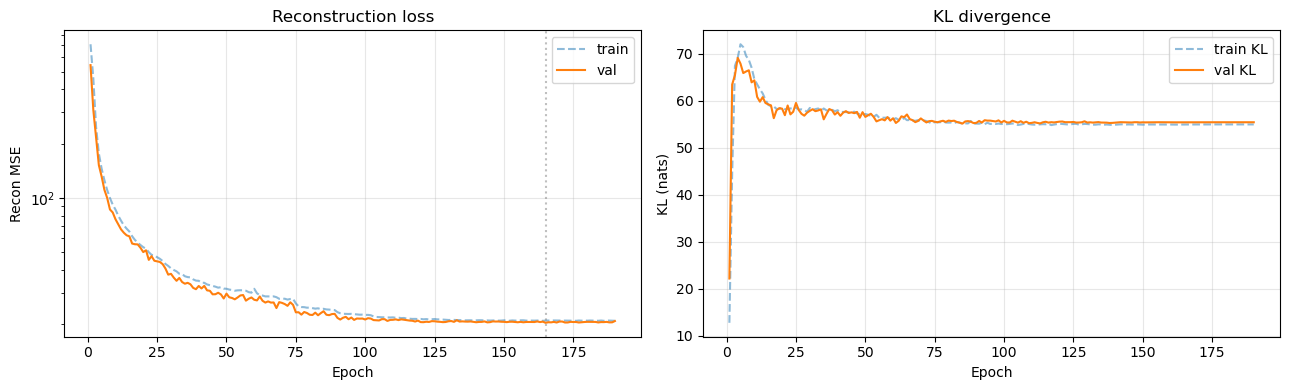

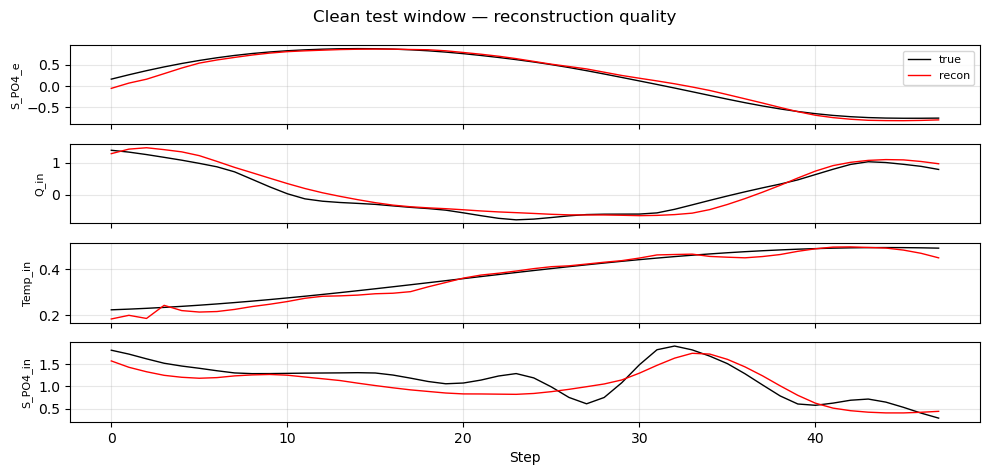

In [ ]:
#TRANING CURVE PLOT

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ep = range(1, len(history['train_recon']) + 1)
ax[0].plot(ep, history['train_recon'], '--', alpha=.5, label='train')
ax[0].plot(ep, history['val_recon'],         label='val')
ax[0].axvline(best_epoch, ls=':', c='gray', alpha=.5)
ax[0].set(xlabel='Epoch', ylabel='Recon MSE', yscale='log', title='Reconstruction loss')
ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(ep, history['train_kl'], '--', alpha=.5, label='train KL')
ax[1].plot(ep, history['val_kl'],         label='val KL')
ax[1].set(xlabel='Epoch', ylabel='KL (nats)', title='KL divergence')
ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

model.eval()
with torch.no_grad():
    x = torch.FloatTensor(X_test[:1]).to(DEVICE)
    xh, _, _ = model(x)
x, xh = x.cpu().numpy(), xh.cpu().numpy()

n_show = min(4, N_VARS)
fig, axes = plt.subplots(n_show, 1, figsize=(10, 1.2 * n_show), sharex=True)
for v in range(n_show):
    axes[v].plot(x[0, :, v],  'k-', lw=1.0, label='true')
    axes[v].plot(xh[0, :, v], 'r-', lw=1.0, label='recon')
    axes[v].set_ylabel(ALL_VARS[v], fontsize=8); axes[v].grid(alpha=.3)
axes[0].legend(fontsize=8); axes[-1].set_xlabel('Step')
plt.suptitle('Clean test window — reconstruction quality')
plt.tight_layout(); plt.show()

> **LLM note:** The following cell was generated with Claude assistance (Level 4 substantial).
> Drafted by Claude, adapted by me, cleaned up and restructed by Claude.

In [ ]:
# SAVE CHECKPOINT

os.makedirs('CHECKPOINTS', exist_ok=True)
hp = BEST_HPARAMS_VAE
ckpt = {
    'state_dict': model.state_dict(),
    'config': {
        'ALL_VARS': ALL_VARS, 'WINDOW_STEPS': INPUT_STEPS,
        'HIDDEN_SIZE': hp.get('hidden_size', HIDDEN_SIZE),
        'LATENT_DIM':  hp.get('latent_dim',  LATENT_DIM),
        'NUM_LAYERS':  hp.get('num_layers',  NUM_LAYERS),
        'DROPOUT':     hp.get('dropout',     DROPOUT),
        'BETA':        beta_use,
        'RESOLUTION_MIN': RESOLUTION_MIN,
    },
    'scaler_type':  'StandardScaler',
    'scaler_mean':  scaler.mean_,
    'scaler_scale': scaler.scale_,
}
path = f'CHECKPOINTS/vae_{DATA_MODE}.pt'
torch.save(ckpt, path)
print(f'saved → {path}')

saved → CHECKPOINTS/vae_bsm2.pt


> **LLM note:** The following cell was generated with Claude assistance (Level 4 substantial).
> Drafted by Claude, adapted by me, cleaned up and restructed by Claude.

In [ ]:
# EXCEL LOG

import openpyxl
LOG_PATH = f'vae_log_{DATA_MODE}.xlsx'

hp = BEST_HPARAMS_VAE
row = {
    'timestamp':    datetime.now().strftime('%Y-%m-%d %H:%M'),
    'data_mode':    DATA_MODE,
    'n_vars':       N_VARS,
    'window_steps': INPUT_STEPS,
    'resolution':   RESOLUTION_MIN,
    'hidden_size':  hp.get('hidden_size', HIDDEN_SIZE),
    'latent_dim':   hp.get('latent_dim',  LATENT_DIM),
    'num_layers':   hp.get('num_layers',  NUM_LAYERS),
    'dropout':      round(hp.get('dropout', DROPOUT), 4),
    'beta':         beta_use,
    'kl_anneal':    kl_anneal_use,
    'lr':           lr_use,
    'batch':        BATCH_SIZE,
    'tuned':        bool(BEST_HPARAMS_VAE),
    'n_params':     sum(p.numel() for p in model.parameters()),
    'best_epoch':   best_epoch,
    'best_val_recon': round(best_val, 4),
    'final_val_kl': round(final_val_kl, 4),
    'train_s':      round(train_time_s, 1),
}

try:
    wb = openpyxl.load_workbook(LOG_PATH); ws = wb.active
except FileNotFoundError:
    wb = openpyxl.Workbook(); ws = wb.active; ws.title = 'vae'
    ws.append(list(row.keys()))
    for c in ws[1]: c.font = openpyxl.styles.Font(bold=True)
ws.append(list(row.values()))
wb.save(LOG_PATH)
print(f'Appended to {LOG_PATH}  (total: {ws.max_row - 1})')

Appended to vae_log_bsm2.xlsx  (total: 2)


> **LLM note:** The following cell was generated with Claude assistance (Level 4 substantial).
> Drafted by Claude, adapted by me, cleaned up and restructed by Claude.

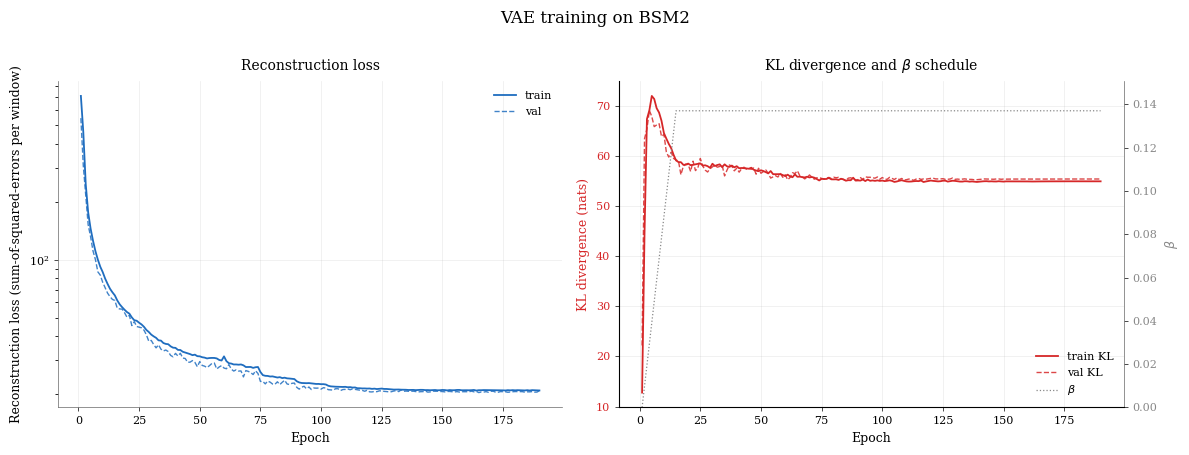

Saved → PLOTS/m2_training_curves.png


In [ ]:
# ══════════════════════════════════════════════════════════════════════
# VAE TRAINING CURVES
# Produces a single figure with two panels:
#   (a) Reconstruction loss (train + val) vs epoch
#   (b) KL divergence (train + val) and β schedule vs epoch
# Saved to PLOTS/m2_training_curves.png.
# Requires the `history` dict produced by the training cell.
# ══════════════════════════════════════════════════════════════════════
import os, numpy as np, matplotlib.pyplot as plt

os.makedirs('PLOTS', exist_ok=True)

# ── Aesthetic helpers (matches M1 plots) ─────────────────────────────
plt.rcParams.update({
    'font.family':       'serif',
    'font.weight':       'light',
    'axes.titleweight':  'normal',
    'axes.labelweight':  'normal',
    'axes.titlesize':    10,
    'axes.labelsize':    9,
    'legend.fontsize':   8,
    'legend.frameon':    False,
    'xtick.labelsize':   8,
    'ytick.labelsize':   8,
})

def style_axis(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for s in ('left', 'bottom'):
        ax.spines[s].set_linewidth(0.5)
        ax.spines[s].set_color('#666')
    ax.tick_params(width=0.5, length=3)
    ax.grid(alpha=0.25, lw=0.5)

# Colours (M1's LSTM blue for VAE, plus a contrasting tone for KL)
C_RECON = '#1f6dbf'
C_KL    = '#d62728'
C_BETA  = '#888888'

# ─────────────────────────────────────────────────────────────────────
# FIGURE — two panels: reconstruction loss, KL + β schedule
# ─────────────────────────────────────────────────────────────────────
ep = np.arange(1, len(history['train_recon']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# (a) Reconstruction loss
ax = axes[0]
ax.plot(ep, history['train_recon'], c=C_RECON, lw=1.3, ls='-',  label='train')
ax.plot(ep, history['val_recon'],   c=C_RECON, lw=1.0, ls='--', alpha=0.85, label='val')
ax.set_xlabel('Epoch')
ax.set_ylabel('Reconstruction loss (sum-of-squared-errors per window)')
ax.set_title('Reconstruction loss', pad=8)
ax.set_yscale('log')
ax.legend(loc='upper right')
style_axis(ax)

# (b) KL term and β schedule
ax = axes[1]
ax.plot(ep, history['train_kl'], c=C_KL, lw=1.3, ls='-',  label='train KL')
ax.plot(ep, history['val_kl'],   c=C_KL, lw=1.0, ls='--', alpha=0.85, label='val KL')
ax.set_xlabel('Epoch')
ax.set_ylabel('KL divergence (nats)', color=C_KL)
ax.tick_params(axis='y', labelcolor=C_KL)
ax.set_title(r'KL divergence and $\beta$ schedule', pad=8)
style_axis(ax)

# β schedule on a secondary axis
ax2 = ax.twinx()
ax2.plot(ep, history['beta'], c=C_BETA, lw=0.9, ls=':', label=r'$\beta$')
ax2.set_ylabel(r'$\beta$', color=C_BETA)
ax2.tick_params(axis='y', labelcolor=C_BETA, width=0.5, length=3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_linewidth(0.5)
ax2.spines['right'].set_color('#666')
ax2.set_ylim(0, max(history['beta']) * 1.1 if max(history['beta']) > 0 else 1)

# Combined legend
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='lower right')

plt.suptitle('VAE training on BSM2', fontsize=12, y=1.00)
plt.tight_layout()
plt.savefig('PLOTS/m2_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved → PLOTS/m2_training_curves.png')

> **LLM note:** The following cell was generated with Claude assistance (Level 4 substantial).
> Drafted by Claude, adapted by me, cleaned up and restructed by Claude.

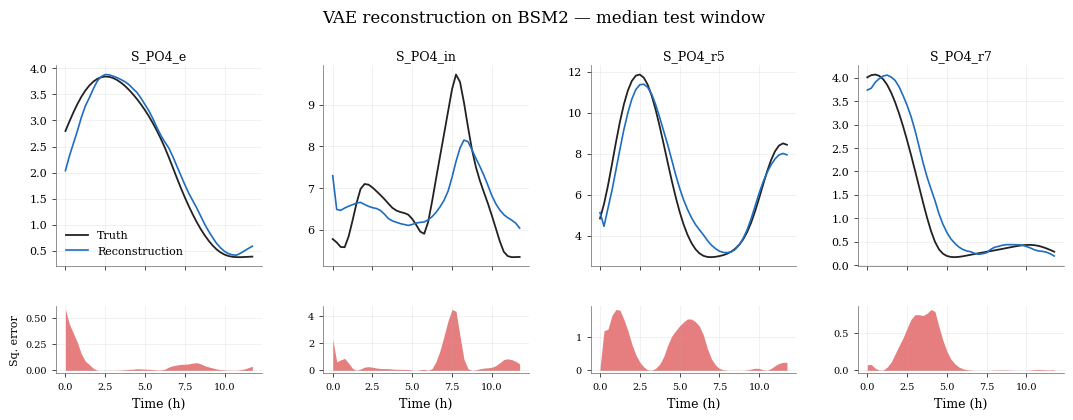

Saved → PLOTS/m2_reconstruction_hero.png


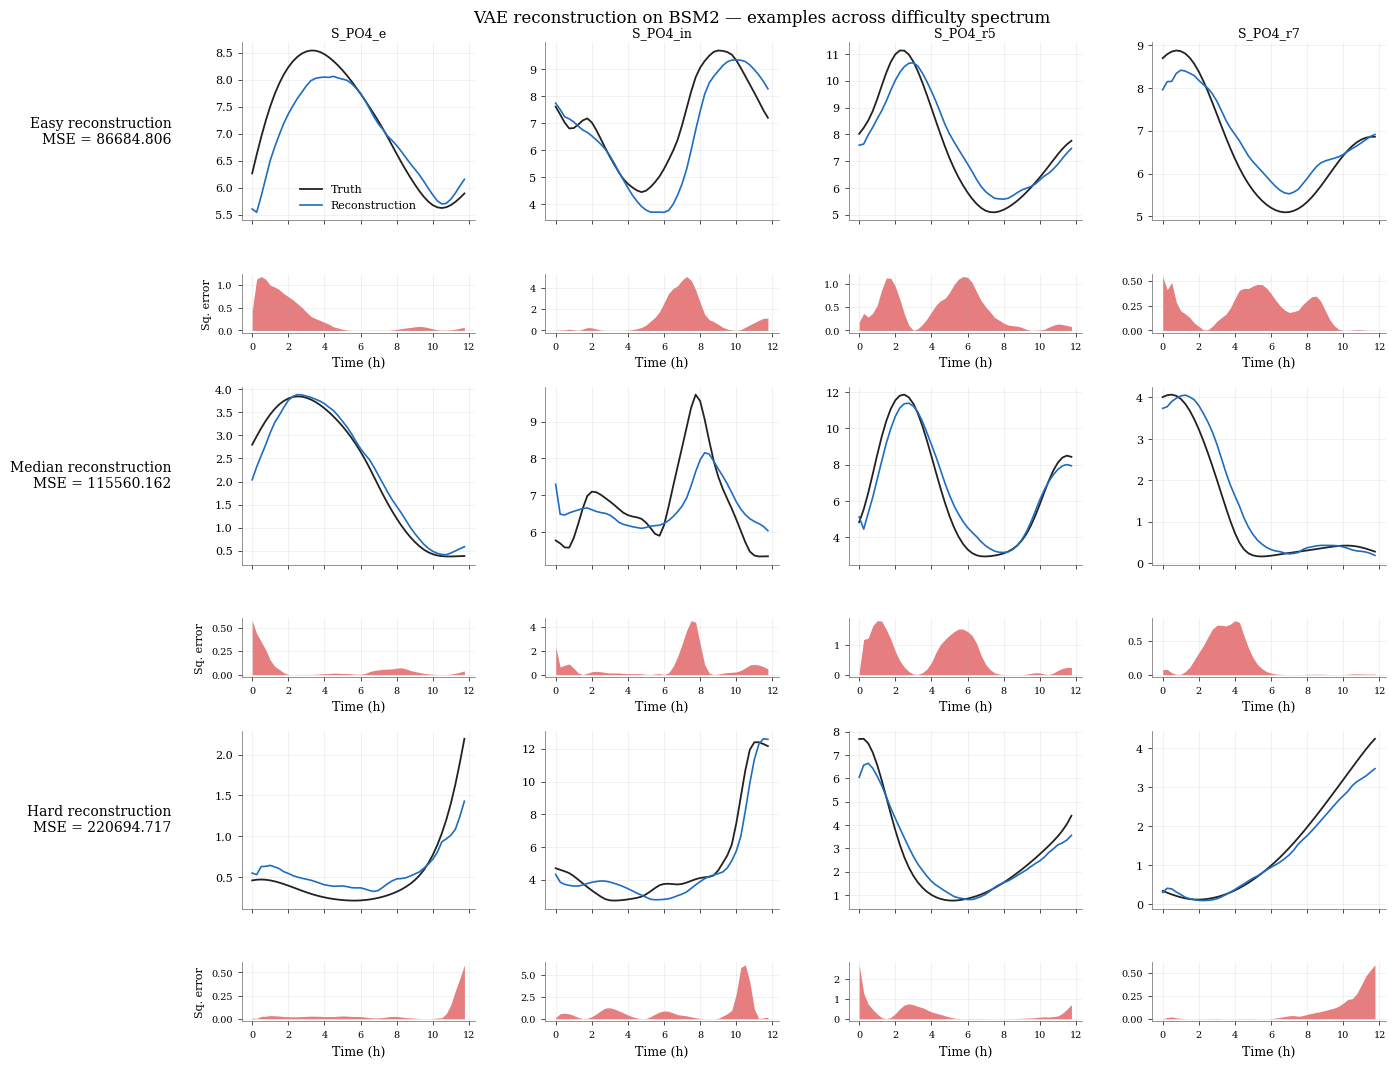

Saved → PLOTS/m2_reconstruction_grid.png


In [ ]:
# ══════════════════════════════════════════════════════════════════════
# VAE RECONSTRUCTION FIGURES
# Requires `model`, `X_test`, `ALL_VARS`, `DEVICE`,
# `INPUT_STEPS`, `RESOLUTION_MIN`, `scaler` to exist.
#
# Produces:
#   PLOTS/m2_reconstruction_hero.png   — 1 window × 4 vars + per-step error
#   PLOTS/m2_reconstruction_grid.png   — 3 windows × 4 vars + per-step error
# ══════════════════════════════════════════════════════════════════════
import os, numpy as np, torch, matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

os.makedirs('PLOTS', exist_ok=True)

# ── Aesthetic helpers (same as M1) ───────────────────────────────────
plt.rcParams.update({
    'font.family':       'serif',
    'font.weight':       'light',
    'axes.titleweight':  'normal',
    'axes.labelweight':  'normal',
    'axes.titlesize':    10,
    'axes.labelsize':    9,
    'legend.fontsize':   8,
    'legend.frameon':    False,
    'xtick.labelsize':   8,
    'ytick.labelsize':   8,
})

def style_axis(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for s in ('left', 'bottom'):
        ax.spines[s].set_linewidth(0.5)
        ax.spines[s].set_color('#666')
    ax.tick_params(width=0.5, length=3)
    ax.grid(alpha=0.25, lw=0.5)

C_TRUE  = '#222222'
C_RECON = '#1f6dbf'
C_ERR   = '#d62728'

# ── Variables to show (target + 3 informative process variables) ─────
SHOW_VARS = ['S_PO4_e', 'S_PO4_in', 'S_PO4_r5', 'S_PO4_r7']
show_idx  = [ALL_VARS.index(v) for v in SHOW_VARS if v in ALL_VARS]
SHOW_VARS = [ALL_VARS[i] for i in show_idx]

# ── Compute reconstructions in original units for test set ───────────
model.eval()
with torch.no_grad():
    x_full = torch.FloatTensor(X_test).to(DEVICE)
    xh_full, _, _ = model(x_full)
x_full  = x_full.cpu().numpy()
xh_full = xh_full.cpu().numpy()

# Inverse-scale back to physical units (StandardScaler)
mean = scaler.mean_; scale = scaler.scale_
x_orig  = x_full  * scale + mean
xh_orig = xh_full * scale + mean

# Per-window total reconstruction error (in original units, MSE)
per_win_mse = ((x_orig - xh_orig) ** 2).mean(axis=(1, 2))

# Pick three windows at 20th / 50th / 80th percentile of reconstruction MSE
order = np.argsort(per_win_mse)
n = len(order)
idx_easy   = order[int(0.20 * (n - 1))]
idx_median = order[int(0.50 * (n - 1))]
idx_hard   = order[int(0.80 * (n - 1))]

# Time axis in hours
t = np.arange(INPUT_STEPS) * RESOLUTION_MIN / 60

# ─────────────────────────────────────────────────────────────────────
# Helper: plot one window across SHOW_VARS, with per-step error below
# `show_col_titles` controls whether variable names appear above (top row)
# ─────────────────────────────────────────────────────────────────────
def plot_window(axes_ts, axes_er, win_idx,
                label_legend=False, show_col_titles=True):
    for col, vi in enumerate(show_idx):
        ax_ts = axes_ts[col]
        ax_er = axes_er[col]
        true_v  = x_orig [win_idx, :, vi]
        recon_v = xh_orig[win_idx, :, vi]
        err     = (true_v - recon_v) ** 2

        ax_ts.plot(t, true_v,  c=C_TRUE,  lw=1.3,
                   label='Truth' if (label_legend and col == 0) else None)
        ax_ts.plot(t, recon_v, c=C_RECON, lw=1.2,
                   label='Reconstruction' if (label_legend and col == 0) else None)
        if show_col_titles:
            ax_ts.set_title(SHOW_VARS[col], pad=4, fontsize=9)
        ax_ts.tick_params(labelbottom=False)
        style_axis(ax_ts)
        if label_legend and col == 0:
            ax_ts.legend(loc='best')

        ax_er.fill_between(t, 0, err, color=C_ERR, alpha=0.6, lw=0)
        ax_er.set_xlabel('Time (h)')
        if col == 0:
            ax_er.set_ylabel('Sq. error', fontsize=8)
        ax_er.tick_params(labelsize=7)
        style_axis(ax_er)

# ─────────────────────────────────────────────────────────────────────
# FIGURE 1 — HERO: 1 window × 4 variables
# ─────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(13, 4.0))
gs  = GridSpec(2, 4, height_ratios=[3, 1], hspace=0.30, wspace=0.30)
axes_ts = [fig.add_subplot(gs[0, c]) for c in range(4)]
axes_er = [fig.add_subplot(gs[1, c], sharex=axes_ts[c]) for c in range(4)]

plot_window(axes_ts, axes_er, idx_median, label_legend=True)

fig.suptitle(f'VAE reconstruction on BSM2 — median test window',
             fontsize=12, y=1.02)
plt.savefig('PLOTS/m2_reconstruction_hero.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → PLOTS/m2_reconstruction_hero.png')


# ─────────────────────────────────────────────────────────────────────
# FIGURE 2 — APPENDIX: 3 windows × 4 variables
# ─────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(13, 11))
# Six rows total: 3 windows × (timeseries + error). Slightly bigger
# hspace between window pairs than within a pair.
gs = GridSpec(6, 4, height_ratios=[3, 1, 3, 1, 3, 1],
              hspace=0.45, wspace=0.30,
              left=0.10, right=0.98, top=0.94, bottom=0.05)

rows = [
    ('Easy reconstruction',   idx_easy,   per_win_mse[idx_easy],   0, 1, True),
    ('Median reconstruction', idx_median, per_win_mse[idx_median], 2, 3, False),
    ('Hard reconstruction',   idx_hard,   per_win_mse[idx_hard],   4, 5, False),
]

for row_label, win_idx, win_mse, row_ts, row_er, is_first in rows:
    axes_ts = [fig.add_subplot(gs[row_ts, c]) for c in range(4)]
    axes_er = [fig.add_subplot(gs[row_er, c], sharex=axes_ts[c]) for c in range(4)]
    plot_window(axes_ts, axes_er, win_idx,
                label_legend=is_first, show_col_titles=is_first)
    # Row label on the far left, outside the leftmost axes
    axes_ts[0].text(-0.30, 0.5,
                    f'{row_label}\nMSE = {win_mse:.3f}',
                    transform=axes_ts[0].transAxes,
                    fontsize=10, fontweight='normal',
                    va='center', ha='right', rotation=0)

fig.suptitle('VAE reconstruction on BSM2 — examples across difficulty spectrum',
             fontsize=12, y=0.97)
plt.savefig('PLOTS/m2_reconstruction_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → PLOTS/m2_reconstruction_grid.png')